# SECOND LAB

Lucas Felipe Hernández Palacio

## 1. Brief context.

<div style="text-align: justify;">

Soil health is defined as "the capacity of a soil to function within ecosystem and land-use boundaries, to sustain biological productivity, maintain environmental quality, and promote plant and animal health" (Doran & Zeiss, 2000; Lehmann et al., 2020). Its assessment has evolved from a productivity-centered approach toward a holistic vision that includes soil biota and the biotic processes affecting soil properties (Zeng et al., 2024).

Mid-infrared spectroscopy (MIR, 2500–25000 nm) has established itself as a non-destructive, rapid-analysis tool for monitoring soil health indicators. This technique identifies characteristic organic and inorganic functional groups, such as clay minerals, iron oxides, and organic matter, through electromagnetic radiation absorption (Viscarra Rossel & McBratney, 2010; Soriano-Disla et al., 2014), and has demonstrated superiority over NIR spectroscopy for predicting soil organic carbon (Reeves, 2010).

The data used in this work come from the *Open Soil Spectral Library* (OSSL), previously introduced in the first laboratory. This initiative compiles spectral information from multiple global sources, including ICRAF-ISRIC and LUCAS, to facilitate the development of predictive models (Viscarra Rossel et al., 2022; Orgiazzi et al., 2018). Specifically, the test dataset contains 250 MIR spectra from 50 soil samples measured with five different FTIR instruments (INST1–INST5) across the 650–4000 cm⁻¹ range with a 2 cm⁻¹ step. However, the transferability of these models across instruments and geographic regions remains a challenge requiring calibration transfer techniques (Safanelli et al., 2025).

</div>

## 2. Advanced data handling with Pandas. 

### Data loading

<p align="justify">
The dataset used in FIRST_LAB is loaded, corresponding to 250 MIR spectra from 50 soil samples measured with five different FTIR instruments. The data is retrieved directly from Google Drive via a public download URL. The <code>pd.read_csv()</code> function from Pandas parses the comma-separated text file and automatically converts it into a DataFrame, the library's main tabular structure, equivalent to an in-memory spreadsheet where each row is a sample and each column is a variable.
</p>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
file_id = '1gdKgdHOxGfeaVUj0OHHFrOneaFbt5o2c'
url = f'https://drive.google.com/uc?id={file_id}&export=download'

soil_spectroscopy = pd.read_csv(url)
soil_spectroscopy.head(5)

,unique_id,instrument,sample_id,650,652,654,656,658,660,662,...,3982,3984,3986,3988,3990,3992,3994,3996,3998,4000
0,U1,INST1,S1139,2.53446,2.52495,2.52004,2.52020,2.52145,2.50962,2.49194,...,1.18839,1.18797,1.18738,1.18698,1.18669,1.18630,1.18579,1.18530,1.18506,1.18525
1,U2,INST1,S1239,2.60417,2.60600,2.60204,2.58584,2.57408,2.57234,2.56945,...,1.27061,1.26969,1.26833,1.26743,1.26721,1.26732,1.26732,1.26700,1.26650,1.26590
2,U3,INST1,S1444,2.42569,2.41961,2.41259,2.40228,2.39089,2.38415,2.37893,...,1.24224,1.24227,1.24214,1.24177,1.24137,1.24112,1.24112,1.24136,1.24177,1.24228
3,U4,INST1,S1484,2.53700,2.52715,2.51345,2.50851,2.51366,2.51775,2.51627,...,1.26346,1.26368,1.26317,1.26224,1.26156,1.26088,1.26004,1.25949,1.25956,1.26061
4,U5,INST1,S1498,2.44423,2.44196,2.42782,2.41031,2.40321,2.40429,2.40328,...,1.27726,1.27669,1.27611,1.27622,1.27664,1.27657,1.27628,1.27609,1.27586,1.27549


<p align="justify">
The dataset contains 250 rows corresponding to the 250 spectral records, and 1679 columns in total: three identification columns (<code>unique_id</code>, <code>instrument</code>, <code>sample_id</code>) and 1676 columns with absorbance values for each wavenumber between 650 and 4000 cm⁻¹ with a 2 cm⁻¹ step.
</p>

**Data type verification:**

<p align="justify">
The <code>type()</code> function confirms that the loaded structure is indeed a Pandas DataFrame. The <code>dtypes</code> attribute reveals the data type assigned to each column: identification columns are of type <em>object</em> (text) and spectral columns are of type <em>float64</em> (64-bit decimal number). The <code>shape</code> attribute returns a tuple with the number of rows and columns, allowing a quick check that the reading was complete.
</p>

In [36]:
print(type(soil_spectroscopy))
print(soil_spectroscopy.shape)
print(soil_spectroscopy.dtypes)

<class 'pandas.core.frame.DataFrame'>
(250, 1679)
unique_id      object
instrument     object
sample_id      object
650           float64
652           float64
               ...   
3992          float64
3994          float64
3996          float64
3998          float64
4000          float64
Length: 1679, dtype: object


### Spectral columns extraction

<p align="justify">
The identification columns are separated from the spectral columns. The first three columns contain metadata for each sample, while the rest correspond to wavenumbers. The <code>wavelengths</code> array is built by taking the spectral column names and converting them to numeric values with <code>astype(float)</code>, since Pandas loads them as text when reading the CSV. This array will serve as the horizontal axis in all spectral plots.
</p>

In [37]:
id_columns = ['unique_id', 'instrument', 'sample_id']
spectral_columns = soil_spectroscopy.columns[3:].tolist()

wavelengths = np.array(spectral_columns).astype(float)

print(f"Spectral range: {wavelengths.min()} - {wavelengths.max()} cm⁻¹")
print(f"Number of wavenumbers: {len(wavelengths)}")

Spectral range: 650.0 - 4000.0 cm⁻¹
Number of wavenumbers: 1676


### Missing data verification

<p align="justify">
Even though the dataset comes from a structured public repository, it is essential to verify the presence of missing values before any analysis. The <code>isna()</code> function generates a boolean DataFrame where <code>True</code> indicates a null value. Chaining <code>.sum()</code> counts the nulls per column, and applying a second <code>.sum()</code> gives the overall total. This process determines whether data imputation is necessary, that is, filling empty spaces with an estimated value such as the mean or median. Given the small size of the test set, losing samples due to missing values would have a considerable impact on subsequent analyses.
</p>

In [38]:
null_per_col = soil_spectroscopy.isna().sum()
total_nulls  = null_per_col.sum()

print(f"Columns with missing values:\n{null_per_col[null_per_col > 0]}")
print(f"\nTotal missing values: {total_nulls}")

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


<p align="justify">
The result confirms that no null values exist in any column of the dataset, so the imputation process is not necessary. This guarantees that each sample has its complete spectrum available for subsequent analyses.
</p>

### Duplicate samples verification

<p align="justify">
Duplicate records are checked using the <code>is_unique</code> attribute applied to the <code>unique_id</code> column, which acts as the unique identifier for each record. A value of <code>True</code> confirms that each row is distinct and that the loading process did not generate accidental duplicates. Additionally, <code>value_counts()</code> is applied to the <code>instrument</code> column to confirm that all five instruments contribute exactly 50 spectra each, guaranteeing a balanced design.
</p>

In [39]:
print("Is unique_id unique?:", soil_spectroscopy['unique_id'].is_unique)
print("\nSamples per instrument:")
print(soil_spectroscopy['instrument'].value_counts())

Is unique_id unique?: True

Samples per instrument:
instrument
INST1    50
INST2    50
INST3    50
INST4    50
INST5    50
Name: count, dtype: int64


### Spectral column order verification

<p align="justify">
For plots and calculations of areas or derivatives to be correct, the spectral columns must be sorted in ascending wavenumber order. A sorted version of the wavelength list is generated with <code>sorted()</code> and compared directly with the original list stored in <code>spectral_columns</code>. The result is stored in <code>cols_in_order</code>: a value of <code>True</code> confirms the order is correct and no reorganization is needed. This step is equivalent to verifying that an X-axis is in ascending sequence before plotting.
</p>

In [40]:
sorted_cols = sorted(spectral_columns, key=lambda x: float(x))
cols_in_order = spectral_columns == sorted_cols
print("Are spectral columns sorted?:", cols_in_order)

Are spectral columns sorted?: True


### Spectral data visualization

<p align="justify">
The complete set of 250 spectra is plotted overlaid to obtain a general overview of the spectral variability of the dataset. The absorbance matrix is extracted from the DataFrame by selecting only the spectral columns with <code>.values</code>, which returns a NumPy array of dimensions 250 × 1676, stored in <code>spectra</code>. Plotting the transpose <code>spectra.T</code> lets Matplotlib interpret each column as an independent series, drawing all 250 spectra in a single command without a loop. The parameter <code>alpha=0.3</code> applies transparency so that regions with higher curve density appear visually darker, facilitating the identification of common patterns.
</p>

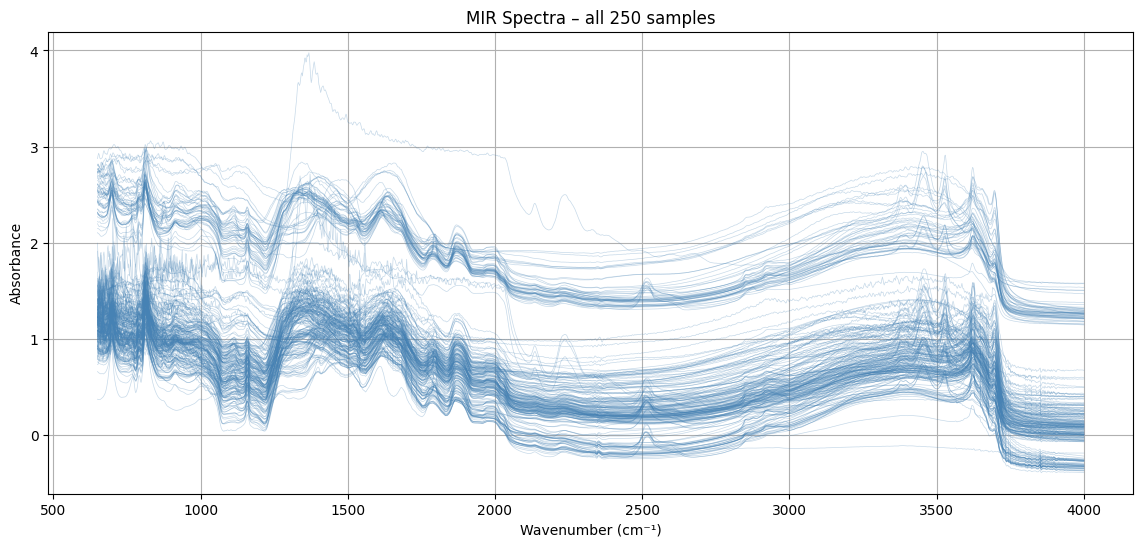

In [41]:
spectra = soil_spectroscopy[spectral_columns].values

plt.figure(figsize=(14, 6))
plt.plot(wavelengths, spectra.T, alpha=0.3, linewidth=0.5, color='steelblue')
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Absorbance')
plt.title('MIR Spectra – all 250 samples')
plt.grid(True)
plt.show()

<p align="justify">
The plot reveals that all spectra share the same pattern of absorption bands characteristic of soil, with pronounced peaks in the 1000–1200 cm⁻¹ region associated with clay minerals (Si-O bonds) and variations in the 1350–1450 cm⁻¹ zone related to organic matter. Differences in magnitude between curves reflect both sample variation and systematic differences between instruments, justifying the need for normalization before further analysis.
</p>

### Spectra by instrument

<p align="justify">
In addition to the global visualization, the individual spectra of each instrument are plotted in separate subplots. The <code>groupby('instrument')</code> method is applied to <code>soil_spectroscopy</code> to obtain the indices of each group, and the corresponding spectral submatrix is extracted by indexing <code>spectra</code> with those indices. This visualization allows identification of whether any instrument behaves systematically different from the rest, or shows greater internal dispersion across its 50 measurements. The same colors from <code>inst_colors</code> are reused to maintain visual consistency throughout the notebook.
</p>

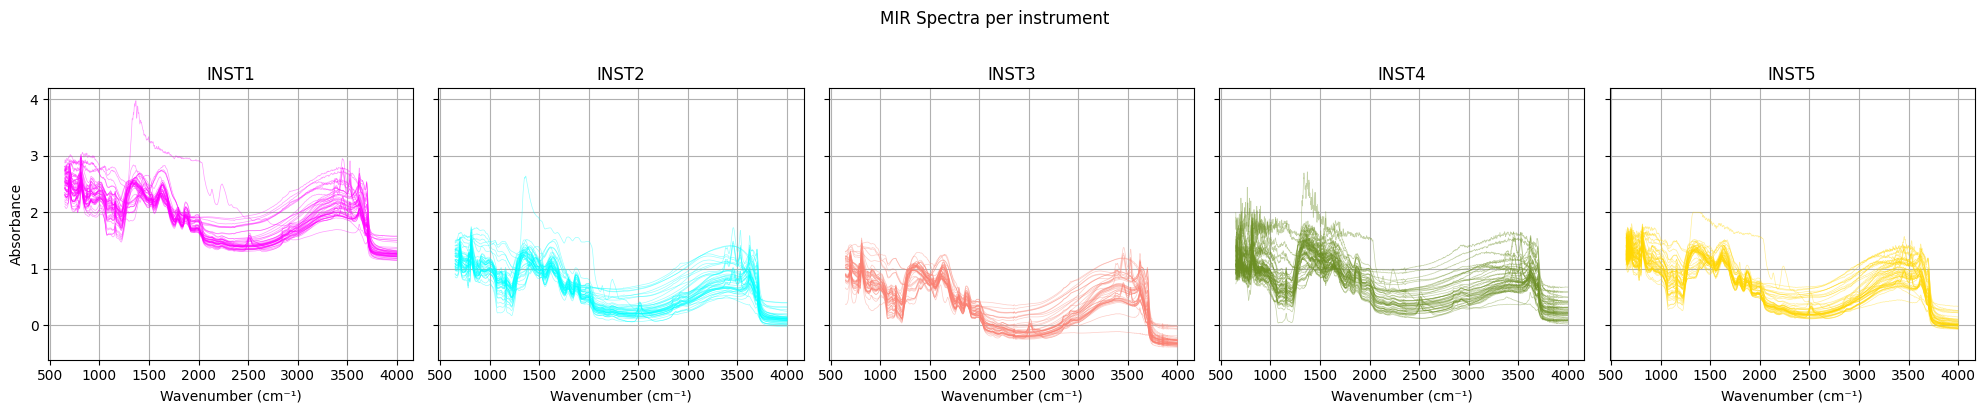

In [42]:
inst_colors = ['magenta', 'cyan', 'salmon', 'olivedrab', 'gold']
instruments = soil_spectroscopy['instrument'].unique()

fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, inst in enumerate(sorted(instruments)):
    idx = soil_spectroscopy[soil_spectroscopy['instrument'] == inst].index
    axs[i].plot(wavelengths, spectra[idx].T,
                alpha=0.4, linewidth=0.5, color=inst_colors[i])
    axs[i].set_title(inst)
    axs[i].set_xlabel('Wavenumber (cm⁻¹)')
    axs[i].grid(True)

axs[0].set_ylabel('Absorbance')
plt.suptitle('MIR Spectra per instrument', y=1.02)
plt.tight_layout()
plt.show()

<p align="justify">
The subplots allow comparison of each instrument's internal dispersion: an instrument with closely grouped curves indicates high reproducibility across its 50 measurements, while widely spread curves may indicate greater sensitivity to measurement conditions. This visualization complements the mean spectrum calculated later and justifies the need for normalization to make the instruments comparable.
</p>

### Edge noise verification

<p align="justify">
FTIR spectrometers can introduce instability at the edges of the measured spectral range, especially near 650–700 cm⁻¹ (detector lower limit) and near 4000 cm⁻¹ (upper limit). To quantify whether this noise is significant, the standard deviation of each wavenumber across all 250 samples is computed with <code>.std(axis=0)</code> and stored in <code>wavenumber_std</code>. This operation returns one value per spectral column, indicating how much the absorbance at that point varies across samples. The median variability of the edges, first and last <code>border_size</code> wavenumbers, stored in <code>border_std</code>, is then compared with the center of the spectrum (<code>interior_std</code>) through the ratio <code>noise_ratio</code>. A value greater than 2 would indicate that the edges are significantly noisier than the center and should be trimmed.
</p>

In [43]:
wavenumber_std = soil_spectroscopy[spectral_columns].std(axis=0)
border_size = 100

border_std = pd.concat([wavenumber_std.head(border_size), wavenumber_std.tail(border_size)])
interior_std = wavenumber_std.iloc[border_size:-border_size]

noise_ratio = border_std.median() / interior_std.median()
print(f"Edge-to-center variability ratio: {noise_ratio:.4f}")

Edge-to-center variability ratio: 0.9748


<p align="justify">
A <code>noise_ratio</code> below 2 indicates that the variability at the spectral edges is not significantly greater than at the center, so no trimming of the spectral range is necessary. The complete 650–4000 cm⁻¹ spectrum is retained for the analysis.
</p>

### Standard Normal Variate (SNV) normalization

<p align="justify">
SNV normalization is applied to remove differences in absorbance magnitude caused primarily by variations in light source intensity, sample concentration, or instrument-related scattering effects. This method transforms each spectrum individually: it subtracts that spectrum's mean and divides by its standard deviation, centering each curve at zero and scaling it to a common variance. This makes all spectra comparable by their characteristic shape rather than their absolute magnitude, preventing a sample from appearing more contaminated simply because its instrument measures at a higher intensity.
</p>
<p align="justify">
The functions <code>mean(axis=1)</code> and <code>std(axis=1)</code> compute the mean (<code>spectrum_mean</code>) and standard deviation (<code>spectrum_std</code>) of each row considering all wavenumbers. The functions <code>sub()</code> and <code>div()</code> apply these operations row-by-row via the <code>axis=0</code> parameter, generating the normalized matrix <code>snv_matrix</code>. The function <code>replace(0, 1)</code> prevents division by zero in case any spectrum has zero standard deviation. Finally, <code>soil_snv</code> combines the identification columns with the normalized matrix.
</p>

In [44]:
spectrum_mean = soil_spectroscopy[spectral_columns].mean(axis=1)
spectrum_std = soil_spectroscopy[spectral_columns].std(axis=1)

snv_matrix = (soil_spectroscopy[spectral_columns]
              .sub(spectrum_mean, axis=0)
              .div(spectrum_std.replace(0, 1), axis=0))

soil_snv = pd.concat([soil_spectroscopy[id_columns].reset_index(drop=True),
                       snv_matrix.reset_index(drop=True)], axis=1)

print("Mean of SNV spectra (expected ~0):", snv_matrix.mean(axis=1).mean().round(6))
print("Std of SNV spectra  (expected ~1):", snv_matrix.std(axis=1).mean().round(6))
print("SNV min / max:", snv_matrix.min().min().round(4), snv_matrix.max().max().round(4))

Mean of SNV spectra (expected ~0): -0.0
Std of SNV spectra  (expected ~1): 1.0
SNV min / max: -2.2174 3.6125


<p align="justify">
The results confirm that SNV normalization was applied correctly: the average mean of each transformed spectrum is close to zero and the average standard deviation is close to one. This indicates that intensity differences between instruments have been removed, and spectra are now comparable solely based on their characteristic spectral shape.
</p>

### SNV normalized spectra visualization

<p align="justify">
The full set of spectra is plotted again, now using the values from <code>snv_matrix</code> extracted as the array <code>snv_values</code>, to visually compare the effect of the transformation against the original plot of <code>spectra</code>. The side-by-side comparison illustrates the scale change while preserving the spectral shape.
</p>

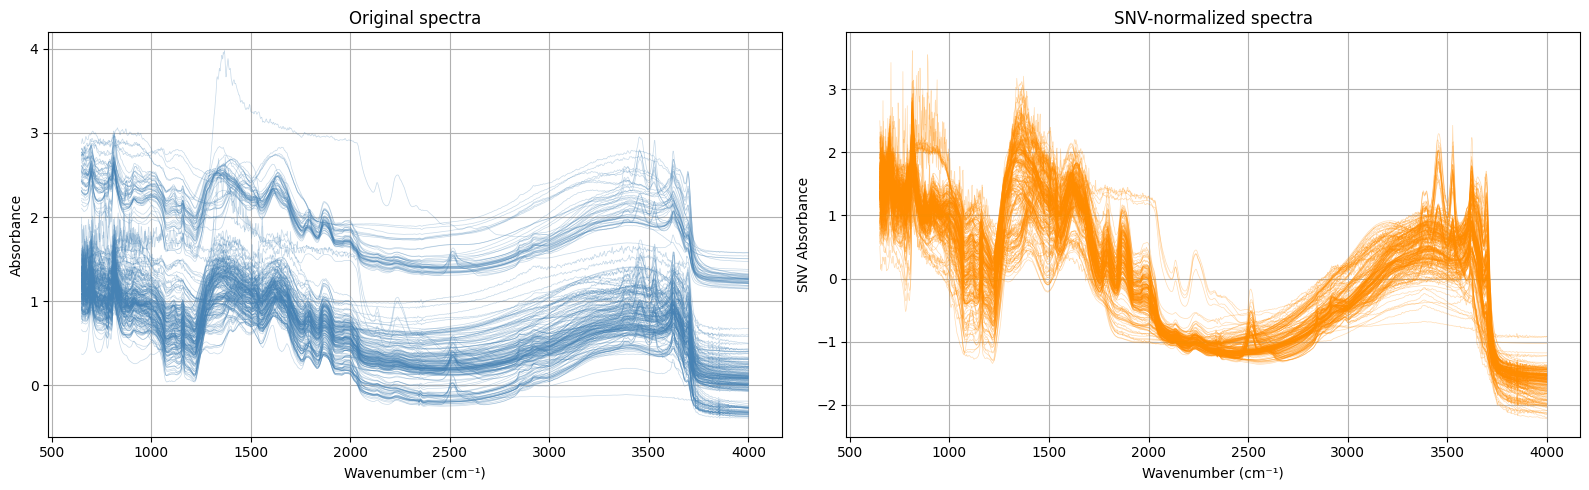

In [45]:
snv_values = snv_matrix.values

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

axs[0].plot(wavelengths, spectra.T, alpha=0.3, linewidth=0.5, color='steelblue')
axs[0].set_title('Original spectra')
axs[0].set_xlabel('Wavenumber (cm⁻¹)')
axs[0].set_ylabel('Absorbance')
axs[0].grid(True)

axs[1].plot(wavelengths, snv_values.T, alpha=0.3, linewidth=0.5, color='darkorange')
axs[1].set_title('SNV-normalized spectra')
axs[1].set_xlabel('Wavenumber (cm⁻¹)')
axs[1].set_ylabel('SNV Absorbance')
axs[1].grid(True)

plt.tight_layout()
plt.show()

<p align="justify">
The normalized plot shows that all spectra are now centered around zero, eliminating magnitude differences between instruments. Unlike the original <code>spectra</code> plot where each instrument exhibited a distinct scale, SNV normalization preserves the spectral shape while adjusting the scale, allowing direct comparison of absorption patterns without the confounding effect of instrumental intensity.
</p>

### Restructuring: wide to long format

<p align="justify">
The DataFrame <code>soil_snv</code> is transformed from <em>wide</em> format to <em>long</em> format using <code>pd.melt()</code>, generating the DataFrame <code>soil_long</code>. In the original format, each wavenumber occupies a column, which is convenient for matrix operations but hinders certain statistical analyses and group visualizations. In the long format, each row represents a single observation: a combination of sample, instrument and wavenumber with its absorbance value. The <code>id_vars</code> parameter specifies the columns that act as identifiers (not transformed), while <code>var_name</code> and <code>value_name</code> name the newly created columns.
</p>

In [46]:
soil_long = soil_snv.melt(
    id_vars=id_columns,
    var_name='wavenumber',
    value_name='absorbance'
)

soil_long['wavenumber'] = soil_long['wavenumber'].astype(float)

print(f"Wide format shape : {soil_snv.shape}")
print(f"Long format shape : {soil_long.shape}")
soil_long.head(8)

Wide format shape : (250, 1679)
Long format shape : (419000, 5)


,unique_id,instrument,sample_id,wavenumber,absorbance
0,U1,INST1,S1139,650.0,1.908077
1,U2,INST1,S1239,650.0,1.831623
2,U3,INST1,S1444,650.0,1.702273
3,U4,INST1,S1484,650.0,1.621827
4,U5,INST1,S1498,650.0,1.652867
5,U6,INST1,S1603,650.0,1.676638
6,U7,INST1,S1809,650.0,1.203503
7,U8,INST1,S2136,650.0,1.684881


<p align="justify">
The restructuring transforms <code>soil_snv</code> from 250 rows × 1679 columns to <code>soil_long</code> with 418,750 rows × 5 columns. This format facilitates filtering by specific spectral ranges and grouping by instrument or sample, operations that will be useful in the statistical analyses of the next section.
</p>

### Mean spectrum per instrument

<p align="justify">
To identify systematic differences between instruments, the mean spectrum of each one is computed using <code>groupby('instrument')</code> on <code>soil_snv</code>, followed by <code>.mean()</code>. The result is stored in <code>inst_avg_spectra</code>, which contains one row per instrument with the average absorbance values at each wavelength. This summarizes the global behavior of each instrument into a single representative curve, regardless of the sample analyzed.
</p>

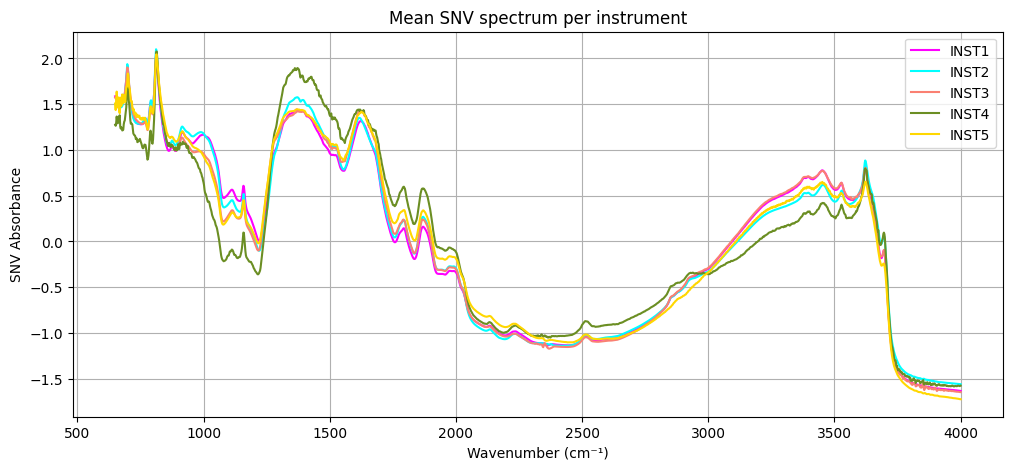

In [47]:
inst_avg_spectra = soil_snv.groupby('instrument')[spectral_columns].mean()

plt.figure(figsize=(12, 5))
for idx, inst in enumerate(inst_avg_spectra.index):
    plt.plot(wavelengths, inst_avg_spectra.loc[inst],
             color=inst_colors[idx], label=inst, linewidth=1.5)

plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('SNV Absorbance')
plt.title('Mean SNV spectrum per instrument')
plt.legend()
plt.grid(True)
plt.show()

<p align="justify">
The mean spectra in <code>inst_avg_spectra</code> show that all five instruments consistently reproduce the same soil characteristic absorption bands. Residual shape differences that persist after SNV normalization correspond to intrinsic instrumental variations of each FTIR device, confirming the instrument transferability challenge reported by Safanelli et al. (2025) and motivating the separability analysis developed in later sections.
</p>

## 3. Feature extraction using OOP

<p align="justify">
Feature extraction consists of transforming raw data, in this case, 1676 absorbance values per spectrum, into a reduced set of numerical descriptors that capture the most relevant properties of each sample. Working directly with 1676 variables per sample introduces redundancy and hinders statistical interpretation. Two feature domains are defined:
</p>

<p align="justify">
<strong>Global spectral domain:</strong> descriptors that summarize the behavior of the full normalized spectrum (energy, mean power, spectral entropy, spectral slope).
</p>

<p align="justify">
<strong>Specific band domain:</strong> descriptors computed over spectral regions with known physical meaning for soils, specifically the clay mineral band (1000–1200 cm⁻¹, Si-O bonds) and the organic matter band (1350–1450 cm⁻¹, C-H bonds).
</p>

<p align="justify">
The implementation follows the Object-Oriented Programming (OOP) paradigm, defining a class <code>SoilFeatureExtractor</code> with independent methods for each domain. This approach allows the extractor to be reused on any subset of the dataset without repeating code.
</p>

### Class definition: SoilFeatureExtractor

<p align="justify">
The class <code>SoilFeatureExtractor</code> receives the normalized spectra matrix and the wavelengths array in its constructor (<code>__init__</code>), storing them as attributes <code>self.spectra</code> and <code>self.wavelengths</code> accessible by all methods.
</p>

<p align="justify">
The method <code>global_features()</code> computes four descriptors over the full spectrum of each sample:
</p>

<p align="justify">
<strong>spectral_energy:</strong> sum of the squares of all absorbance values. Represents the total energy of the spectrum. A high value indicates a spectrum with larger absorbance magnitudes, which may be associated with higher concentrations of absorbing components in the soil.
</p>

<p align="justify">
<strong>mean_power:</strong> spectral energy divided by the number of wavelengths. Equivalent to the average power per spectral point, allowing comparison of samples measured over different ranges without the number of points affecting the result.
</p>

<p align="justify">
<strong>spectral_entropy:</strong> measures how distributed the energy is across the spectrum by normalizing each point's energy relative to the total (<code>energy_dist</code>) and applying Shannon's entropy formula: $H = -\sum p_i \log(p_i)$. A high value indicates uniformly distributed energy (complex spectrum); a low value indicates energy concentrated in few bands (spectrum dominated by a specific component).
</p>

<p align="justify">
<strong>spectral_slope:</strong> slope of the linear trend line fitted over the full spectrum, computed with <code>np.polyfit(degree=1)</code>. A positive value indicates absorbance increases with wavenumber; a negative value indicates it decreases. This descriptor captures the overall tilt of the spectrum, which may be related to organic matter content or scattering effects not removed by SNV normalization.
</p>

<p align="justify">
The method <code>band_descriptors()</code> computes three descriptors over each spectral band of interest, using <code>band_mask</code> to select the wavenumbers within the specified range and <code>band_data</code> to extract the corresponding absorbance values:
</p>

<p align="justify">
<strong>_area:</strong> area under the curve computed with the trapezoidal rule (<code>np.trapezoid</code>). Quantifies total absorption in that region, which is proportional to the concentration of the associated component.
</p>

<p align="justify">
<strong>_peak:</strong> maximum absorbance value within the band. Identifies the most intense absorption peak, corresponding to the strongest resonance frequency of the analyzed functional group.
</p>

<p align="justify">
<strong>_std:</strong> standard deviation of absorbance within the band. Measures the internal variability of the spectrum in that region; a high deviation indicates multiple peaks or an irregular shape, which may reflect the presence of several overlapping minerals or compounds.
</p>

In [48]:
from scipy.stats import entropy

class SoilFeatureExtractor:

    def __init__(self, spectra, wavelengths):
        self.spectra     = spectra
        self.wavelengths = wavelengths

    def global_features(self):
        result = pd.DataFrame()

        sq           = np.square(self.spectra)
        total_energy = sq.sum(axis=1)

        result['spectral_energy']  = total_energy
        result['mean_power']       = total_energy / self.spectra.shape[1]

        energy_dist = (sq.T / total_energy).T
        result['spectral_entropy'] = np.array([entropy(row + 1e-12) for row in energy_dist])

        slopes = np.array([np.polyfit(self.wavelengths, row, 1)[0] for row in self.spectra])
        result['spectral_slope'] = slopes

        return result

    def band_descriptors(self, wn_min, wn_max, label):
        band_mask = (self.wavelengths >= wn_min) & (self.wavelengths <= wn_max)
        band_data = self.spectra[:, band_mask]
        band_axis = self.wavelengths[band_mask]

        result = pd.DataFrame()
        result[f'{label}_area'] = np.trapezoid(band_data, x=band_axis, axis=1)
        result[f'{label}_peak'] = band_data.max(axis=1)
        result[f'{label}_std']  = band_data.std(axis=1)

        return result

### Preparing input data

<p align="justify">
The SNV-normalized spectra matrix is extracted from the DataFrame <code>soil_snv</code> as a NumPy array using <code>.values</code>, stored in <code>snv_array</code>. This step is necessary because the class methods work directly with NumPy arrays, making matrix operations more efficient than on a DataFrame. The array dimensions are verified to confirm 250 samples and 1676 wavelengths.
</p>

In [49]:
snv_array = soil_snv[spectral_columns].values

print(f"SNV spectra matrix shape : {snv_array.shape}")
print(f"Wavelengths array shape  : {wavelengths.shape}")

SNV spectra matrix shape : (250, 1676)
Wavelengths array shape  : (1676,)


### Instantiation and feature extraction

<p align="justify">
The object <code>soil_extractor</code> of class <code>SoilFeatureExtractor</code> is created by passing <code>snv_array</code> and <code>wavelengths</code>. From this object, three methods are called: <code>global_features()</code> generates <code>global_desc</code> with the global spectral domain descriptors, and <code>band_descriptors()</code> is called twice generating <code>clay_desc</code> and <code>organic_desc</code> for each band of interest. The <code>label</code> parameter assigns a distinctive prefix to each column according to the analyzed band.
</p>

In [50]:
soil_extractor = SoilFeatureExtractor(snv_array, wavelengths)

global_desc  = soil_extractor.global_features()
clay_desc    = soil_extractor.band_descriptors(1000, 1200, label='clay')
organic_desc = soil_extractor.band_descriptors(1350, 1450, label='organic')

print("Global features shape  :", global_desc.shape)
print("Clay band shape        :", clay_desc.shape)
print("Organic band shape     :", organic_desc.shape)

Global features shape  : (250, 4)
Clay band shape        : (250, 3)
Organic band shape     : (250, 3)


<p align="justify">
Each method returns a DataFrame with 250 rows (one per sample). The three DataFrames, <code>global_desc</code>, <code>clay_desc</code>, and <code>organic_desc</code>, will be combined in the next step into a single feature table ready for statistical analysis.
</p>

### Verification of individual domains

<p align="justify">
Before combining, the first rows of <code>global_desc</code>, <code>clay_desc</code>, and <code>organic_desc</code> are printed to verify that the computed values are coherent and that no columns contain NaN or unexpected values.
</p>

In [51]:
print("=== Global spectral features ===")
print(global_desc.head())

print("\n=== Clay band features (1000–1200 cm⁻¹) ===")
print(clay_desc.head())

print("\n=== Organic matter features (1350–1450 cm⁻¹) ===")
print(organic_desc.head())

=== Global spectral features ===
   spectral_energy  mean_power  spectral_entropy  spectral_slope
0           1675.0    0.999403          7.012935       -0.000621
1           1675.0    0.999403          7.024825       -0.000605
2           1675.0    0.999403          6.987008       -0.000693
3           1675.0    0.999403          7.072775       -0.000549
4           1675.0    0.999403          7.005916       -0.000675

=== Clay band features (1000–1200 cm⁻¹) ===
    clay_area  clay_peak  clay_std
0  219.386007   1.550539  0.266727
1  183.005879   1.257051  0.186459
2  163.557607   1.215614  0.224870
3  113.376629   1.091652  0.267607
4  162.344405   1.190785  0.215673

=== Organic matter features (1350–1450 cm⁻¹) ===
   organic_area  organic_peak  organic_std
0     92.046752      1.496745     0.390964
1    111.120785      1.908798     0.541944
2    167.569312      1.880396     0.160305
3    141.884897      1.565609     0.129280
4    164.566201      1.835066     0.143175


### Final feature table

<p align="justify">
The three DataFrames are joined horizontally with <code>pd.concat()</code> using <code>axis=1</code>. The function <code>reset_index(drop=True)</code> ensures that the row indices of <code>global_desc</code>, <code>clay_desc</code>, and <code>organic_desc</code> are aligned before joining, preventing accidental row shifts. The <code>instrument</code> column from <code>soil_snv</code> is also added to preserve the label of each sample. The result is stored in <code>feature_table</code>, which will be the input for the statistical and separability analyses.
</p>

In [52]:
feature_table = pd.concat([
    soil_snv[['instrument', 'sample_id']].reset_index(drop=True),
    global_desc.reset_index(drop=True),
    clay_desc.reset_index(drop=True),
    organic_desc.reset_index(drop=True)
], axis=1)

print("Final feature table shape:", feature_table.shape)
feature_table.head()

Final feature table shape: (250, 12)


,instrument,sample_id,spectral_energy,mean_power,spectral_entropy,spectral_slope,clay_area,clay_peak,clay_std,organic_area,organic_peak,organic_std
0,INST1,S1139,1675.0,0.999403,7.012935,-0.000621,219.386007,1.550539,0.266727,92.046752,1.496745,0.390964
1,INST1,S1239,1675.0,0.999403,7.024825,-0.000605,183.005879,1.257051,0.186459,111.120785,1.908798,0.541944
2,INST1,S1444,1675.0,0.999403,6.987008,-0.000693,163.557607,1.215614,0.224870,167.569312,1.880396,0.160305
3,INST1,S1484,1675.0,0.999403,7.072775,-0.000549,113.376629,1.091652,0.267607,141.884897,1.565609,0.129280
4,INST1,S1498,1675.0,0.999403,7.005916,-0.000675,162.344405,1.190785,0.215673,164.566201,1.835066,0.143175


<p align="justify">
The table <code>feature_table</code> contains 250 rows and 12 columns: two identification columns (<code>instrument</code>, <code>sample_id</code>) and ten numerical descriptors distributed across the two defined domains. This compact table summarizes the information from 1676 spectral variables into 10 interpretable features, preserving the most relevant properties for characterizing the mineralogical and organic composition of each soil sample.
</p>

## 4. Statistical analysis of custom data and feature extraction

<p align="justify">
With the features extracted in the previous section, a comprehensive statistical analysis of the feature space is carried out. The goal is to determine whether samples measured with different instruments show statistically significant differences, and which features are most relevant for distinguishing between groups. This analysis is structured in five stages: descriptive statistics, correlation between features, standardized distribution by domain, formal statistical tests (ANOVA and Fisher Ratio), and separability visualization.
</p>

### Feature matrix preparation

<p align="justify">
The feature matrix <code>X</code> is defined by selecting only the numerical columns from <code>feature_table</code>, excluding the identification columns. Column names are grouped by domain into <code>global_cols</code>, <code>clay_cols</code>, and <code>organic_cols</code>, whose union forms <code>desc_cols</code>. This separation is necessary because statistical operations work exclusively on numerical values, and the grouping will facilitate visual identification of each domain in the plots.
</p>

In [53]:
from scipy import stats

global_cols  = ['spectral_energy', 'mean_power', 'spectral_entropy', 'spectral_slope']
clay_cols = ['clay_area', 'clay_peak', 'clay_std']
organic_cols = ['organic_area', 'organic_peak', 'organic_std']
desc_cols = global_cols + clay_cols + organic_cols

X = feature_table[desc_cols].copy()

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (250, 10)


,spectral_energy,mean_power,spectral_entropy,spectral_slope,clay_area,clay_peak,clay_std,organic_area,organic_peak,organic_std
0,1675.0,0.999403,7.012935,-0.000621,219.386007,1.550539,0.266727,92.046752,1.496745,0.390964
1,1675.0,0.999403,7.024825,-0.000605,183.005879,1.257051,0.186459,111.120785,1.908798,0.541944
2,1675.0,0.999403,6.987008,-0.000693,163.557607,1.215614,0.224870,167.569312,1.880396,0.160305
3,1675.0,0.999403,7.072775,-0.000549,113.376629,1.091652,0.267607,141.884897,1.565609,0.129280
4,1675.0,0.999403,7.005916,-0.000675,162.344405,1.190785,0.215673,164.566201,1.835066,0.143175


### Descriptive statistics

<p align="justify">
Before analyzing relationships between variables, it is necessary to understand the individual distribution of each feature. The <code>describe()</code> function from Pandas automatically computes count, mean, standard deviation, minimum, the 25th, 50th and 75th percentiles, and maximum for each column. This summary allows quick detection of whether any feature has a very different scale from the others, whether extreme values could distort the analysis, or whether the distribution is highly asymmetric. The result is transposed with <code>.T</code> for easier reading when there are many columns.
</p>

In [54]:
desc_stats = X.describe().T.round(4)
print("Descriptive statistics per feature:")
desc_stats

Descriptive statistics per feature:


,count,mean,std,min,25%,50%,75%,max
spectral_energy,250.0,1675.0000,0.0000,1675.0000,1675.0000,1675.0000,1675.0000,1675.0000
mean_power,250.0,0.9994,0.0000,0.9994,0.9994,0.9994,0.9994,0.9994
spectral_entropy,250.0,6.9463,0.1049,6.5481,6.9052,6.9497,7.0223,7.1404
spectral_slope,250.0,-0.0006,0.0001,-0.0008,-0.0006,-0.0006,-0.0005,-0.0003
clay_area,250.0,79.7329,89.1103,-184.1545,22.7456,90.9341,141.9216,248.9659
clay_peak,250.0,0.9885,0.3758,-0.2238,0.8012,1.0354,1.2196,1.9087
clay_std,250.0,0.2939,0.1196,0.0530,0.2088,0.2682,0.3776,0.5966
organic_area,250.0,148.7338,52.0845,20.4384,110.5955,149.8148,186.9534,258.3933
organic_peak,250.0,1.7388,0.5584,0.2961,1.3782,1.7637,2.1013,3.2081
organic_std,250.0,0.1654,0.0846,0.0498,0.1129,0.1572,0.1930,0.5985


<p align="justify">
The descriptive statistics confirm that features operate at very different scales: <code>spectral_energy</code> and <code>mean_power</code> have magnitudes distinct from <code>spectral_entropy</code> or <code>spectral_slope</code>. This justifies the Z-score standardization applied in the domain distribution step, so that no variable dominates the analysis due to its absolute magnitude rather than its informational content.
</p>

### Correlation matrix

<p align="justify">
The correlation matrix <code>corr_matrix</code> quantifies the linear relationship between each pair of features, with values between −1 (perfect negative correlation) and 1 (perfect positive correlation). It is computed with <code>X.corr()</code>, which applies the Pearson coefficient by default. This operation identifies redundant features: if two variables have a very high correlation (close to ±1), they carry nearly identical information and one could be removed without losing relevant information. Conversely, correlations near zero between different domains indicate that each domain captures independent aspects of the spectrum, which is desirable in a feature space.
</p>

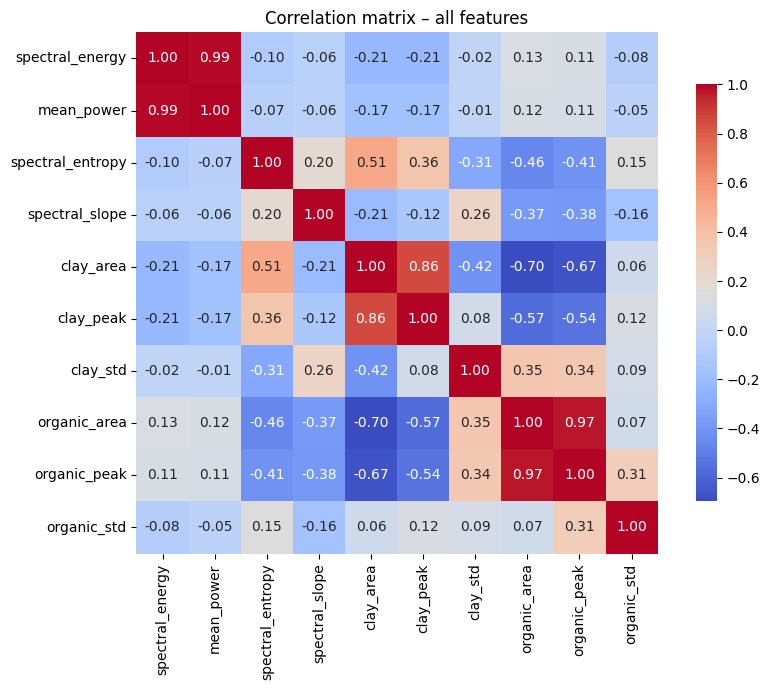

In [55]:
import seaborn as sns

corr_matrix = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix – all features")
plt.tight_layout()
plt.show()

<p align="justify">
The matrix <code>corr_matrix</code> reveals which features are related within each domain and how independent the domains are from each other. High correlations within the same domain (e.g., between <code>spectral_energy</code> and <code>mean_power</code>, which share the same computation base) are expected, while low correlations between the global domain and the specific bands confirm that each feature group describes distinct aspects of the spectrum.
</p>

### Standardized distribution by domain

<p align="justify">
To compare the three feature domains on the same scale, Z-score standardization is applied to <code>X</code>, generating the DataFrame <code>Z</code>: each column's mean is subtracted and divided by its standard deviation. This transforms all variables to a common scale with mean 0 and standard deviation 1, removing the effect of original units. Without this transformation, features with large absolute values (such as <code>spectral_energy</code>) would visually dominate features of smaller magnitude (such as <code>spectral_entropy</code>), even if both have equal discriminative importance.
</p>
<p align="justify">
After standardizing, <code>melt()</code> converts <code>Z</code> to long format in <code>desc_long</code>, allowing a domain label to be assigned to each feature via <code>domain_labels</code> and all groups to be plotted together using <code>domain_palette</code> in a single violin plot. The numerical summary is stored in <code>domain_stats</code>. The violin plot combines the shape of the distribution (like a rotated histogram) with an internal boxplot, simultaneously showing dispersion, median, and data density.
</p>

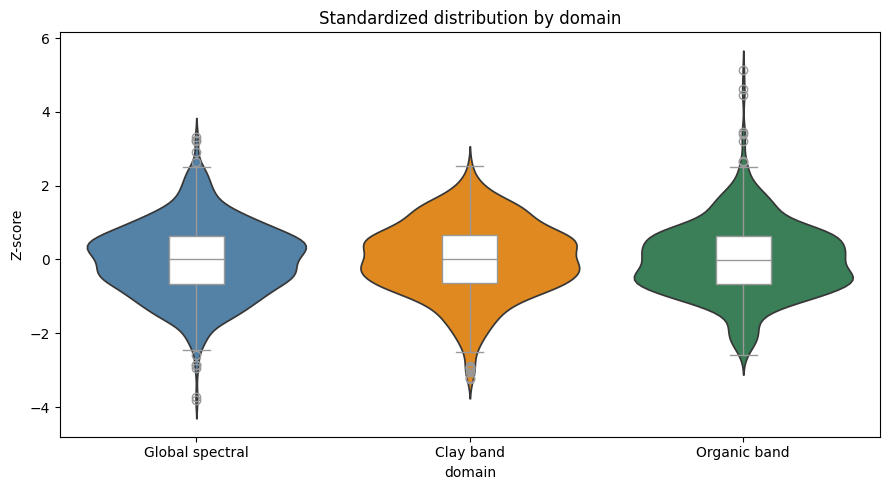

In [56]:
Z = (X - X.mean()) / X.std(ddof=0)

desc_long = Z.melt(var_name='descriptor', value_name='z_score')

domain_labels = {col: 'Global spectral' for col in global_cols}
domain_labels.update({col: 'Clay band' for col in clay_cols})
domain_labels.update({col: 'Organic band' for col in organic_cols})
desc_long['domain'] = desc_long['descriptor'].map(domain_labels)

domain_palette = {'Global spectral': 'steelblue',
                  'Clay band': 'darkorange',
                  'Organic band': 'seagreen'}

plt.figure(figsize=(9, 5))
sns.violinplot(data=desc_long, x='domain', y='z_score', hue='domain',
               inner=None, palette=domain_palette, legend=False)
sns.boxplot(data=desc_long, x='domain', y='z_score', hue='domain',
            width=0.2, showcaps=True, legend=False,
            boxprops={'zorder': 2},
            palette={k: 'white' for k in domain_palette})
plt.title("Standardized distribution by domain")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

<p align="justify">
The violin plot of <code>desc_long</code> allows visual comparison of which domain shows greater dispersion and variability across samples. A domain with a wider distribution indicates its features differentiate more between samples, suggesting greater discriminative power. A very compact, zero-centered domain indicates its features are similar across all samples and contribute little separating capacity. The numerical summary in <code>domain_stats</code> complements this observation with exact values.
</p>

### Correlation between domains

<p align="justify">
To assess whether the three domains describe independent aspects of the spectrum, a summary index per domain is computed by averaging the standardized columns of <code>Z</code>: <code>global_idx</code>, <code>clay_idx</code>, and <code>organic_idx</code>. These are combined into <code>domain_idx</code> and their mutual correlation is stored in <code>idx_corr</code>. A high correlation between two indices indicates both domains capture the same information and one may be redundant. A low or null correlation confirms that each domain provides complementary and independent information, justifying keeping all three in the analysis.
</p>

Inter-domain index correlation:
             GlobalIdx  ClayIdx  OrganicIdx
GlobalIdx       1.000    0.024      -0.210
ClayIdx         0.024    1.000      -0.314
OrganicIdx     -0.210   -0.314       1.000


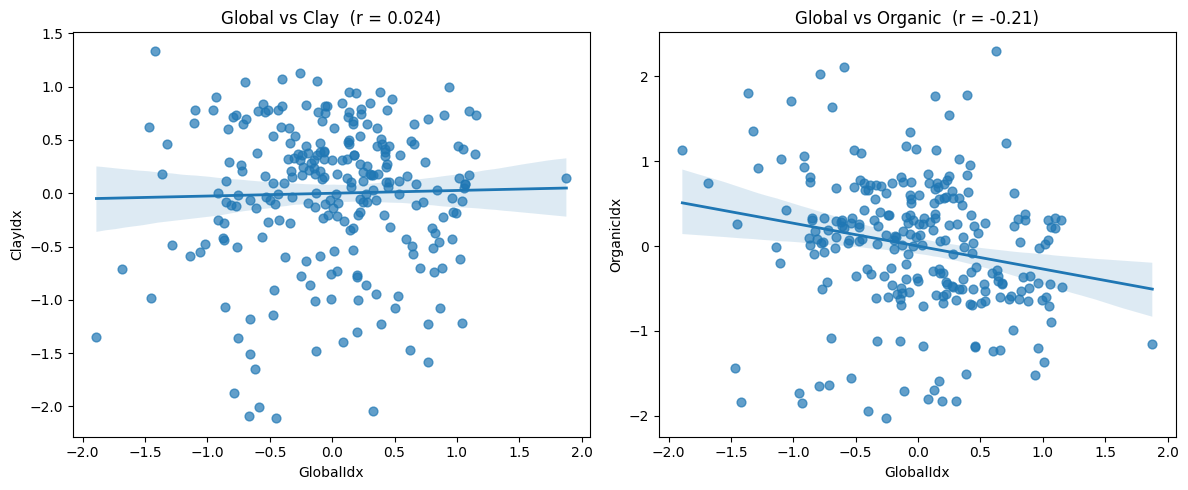

In [57]:
global_idx  = Z[global_cols].mean(axis=1)
clay_idx = Z[clay_cols].mean(axis=1)
organic_idx = Z[organic_cols].mean(axis=1)

domain_idx = pd.DataFrame({
    'GlobalIdx':  global_idx,
    'ClayIdx': clay_idx,
    'OrganicIdx': organic_idx
})

idx_corr = domain_idx.corr().round(3)
print("Inter-domain index correlation:\n", idx_corr)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=domain_idx, x='GlobalIdx', y='ClayIdx',
            scatter_kws={'s': 40, 'alpha': 0.7},
            line_kws={'linewidth': 2}, ax=axs[0])
axs[0].set_title(f"Global vs Clay  (r = {idx_corr.loc['GlobalIdx','ClayIdx']})")

sns.regplot(data=domain_idx, x='GlobalIdx', y='OrganicIdx',
            scatter_kws={'s': 40, 'alpha': 0.7},
            line_kws={'linewidth': 2}, ax=axs[1])
axs[1].set_title(f"Global vs Organic  (r = {idx_corr.loc['GlobalIdx','OrganicIdx']})")

plt.tight_layout()
plt.show()

<p align="justify">
The scatter plots with regression lines visually show the degree of association between <code>GlobalIdx</code>, <code>ClayIdx</code>, and <code>OrganicIdx</code>. A point cloud with no clear trend (near-horizontal line) confirms domain independence. A marked ascending or descending trend would indicate redundancy between feature groups.
</p>

### Selecting the number of groups (K-Means)

<p align="justify">
Since the dataset has no predefined class labels for the samples, the K-Means algorithm is applied on <code>Z</code> to discover natural groups within the feature space. K-Means assigns each sample to the group whose centroid (midpoint) is closest, minimizing internal within-group distance. The results for each value of <em>k</em> are stored in <code>clustering_results</code> and the assigned labels in <code>cluster_labels</code>. Three complementary metrics are evaluated to determine the optimal number of groups:
</p>

<p align="justify">
<strong>Silhouette Score:</strong> measures how similar each sample is to its own group compared to the nearest group. Values close to 1 indicate well-separated and compact groups.
</p>

<p align="justify">
<strong>Calinski-Harabasz Index:</strong> ratio between between-group dispersion and within-group dispersion. Higher values indicate better defined groups.
</p>

<p align="justify">
<strong>Davies-Bouldin Index:</strong> average similarity between each group and its nearest neighbor. Lower values indicate better separation.
</p>

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

clustering_results = []
cluster_labels     = {}

for n_clusters in range(2, 6):
    km  = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    lbl = km.fit_predict(Z)
    cluster_labels[n_clusters] = lbl

    clustering_results.append({
        'k':                 n_clusters,
        'silhouette':        silhouette_score(Z, lbl),
        'calinski_harabasz': calinski_harabasz_score(Z, lbl),
        'davies_bouldin':    davies_bouldin_score(Z, lbl)
    })

clustering_df = pd.DataFrame(clustering_results).round(3)
print("Clustering metrics per k:\n", clustering_df)

best_k       = int(clustering_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
group_labels = cluster_labels[best_k]
print(f"\nBest k by Silhouette score: {best_k}")

Clustering metrics per k:
    k  silhouette  calinski_harabasz  davies_bouldin
0  2       0.218             79.335           1.653
1  3       0.171             60.750           1.707
2  4       0.187             55.220           1.692
3  5       0.210             54.366           1.508

Best k by Silhouette score: 2


### ANOVA and Fisher Ratio

<p align="justify">
With the groups defined by K-Means in <code>group_labels</code>, two statistical tests are applied to determine which features in <code>desc_cols</code> truly differentiate the groups. ANOVA compares means between groups, producing an F statistic and a p-value (significant if p < 0.05). The function <code>compute_fisher()</code> is defined manually since it does not exist in standard libraries: it computes <code>group_means</code> and <code>group_vars</code> per group, then returns the ratio between <code>between_var</code> and <code>within_var</code>. A high ratio indicates high discriminative power. Results are accumulated in <code>anova_records</code> and <code>fisher_records</code>, then converted into the sorted DataFrames <code>anova_results</code> and <code>fisher_results</code>.
</p>

In [59]:
def compute_fisher(values, group_labels):
    unique_groups = np.unique(group_labels)
    group_means   = np.array([values[group_labels == g].mean() for g in unique_groups])
    group_vars    = np.array([values[group_labels == g].var(ddof=1) for g in unique_groups])
    within_var    = group_vars.mean()
    if within_var == 0:
        return np.nan
    between_var = group_means.var(ddof=1)
    return between_var / within_var

anova_records  = []
fisher_records = []

for col in desc_cols:
    col_groups = [X.loc[group_labels == g, col].values for g in np.unique(group_labels)]
    F_stat, p_val = stats.f_oneway(*col_groups)
    anova_records.append({'feature': col, 'F': round(F_stat, 4), 'p_value': round(p_val, 4)})
    fisher_records.append({'feature': col,
                           'FisherRatio': round(compute_fisher(X[col].values, group_labels), 4)})

anova_results  = pd.DataFrame(anova_records).sort_values('p_value').reset_index(drop=True)
fisher_results = pd.DataFrame(fisher_records).sort_values('FisherRatio', ascending=False).reset_index(drop=True)

print("ANOVA results:\n", anova_results)
print("\nFisher Ratio results:\n", fisher_results)

ANOVA results:
             feature         F  p_value
0    spectral_slope   30.9858   0.0000
1  spectral_entropy  121.4078   0.0000
2         clay_peak   64.8140   0.0000
3         clay_area  156.7522   0.0000
4          clay_std   40.7871   0.0000
5      organic_area  426.4970   0.0000
6      organic_peak  333.1239   0.0000
7   spectral_energy    5.2306   0.0230
8        mean_power    5.2337   0.0230
9       organic_std    0.0475   0.8277

Fisher Ratio results:
             feature  FisherRatio
0      organic_area       3.5342
1      organic_peak       2.7512
2         clay_area       1.2352
3  spectral_entropy       0.9828
4         clay_peak       0.5064
5          clay_std       0.3290
6    spectral_slope       0.2546
7        mean_power       0.0160
8       organic_std       0.0004
9   spectral_energy       0.0000


<p align="justify">
Features with high F values and p-values below 0.05 in <code>anova_results</code>, and with a high Fisher Ratio in <code>fisher_results</code>, are the most informative in the feature space and will carry the greatest weight in the separability analysis of the next section. Features with p above 0.05 show no statistically significant differences between groups and contribute little to discrimination.
</p>

### Fisher Ratio visualization

<p align="justify">
To complement the <code>fisher_results</code> table, the Fisher Ratio of each feature is plotted as a horizontal bar chart. This type of plot facilitates direct visual comparison of discriminative power across all features, sorted from highest to lowest. The bars are colored by the domain to which each feature belongs, reusing <code>domain_palette</code> to maintain consistency throughout the notebook. The vertical dashed reference line at x=1 marks the threshold: features with a Fisher Ratio above 1 have between-group variance greater than within-group variance, indicating positive separability.
</p>

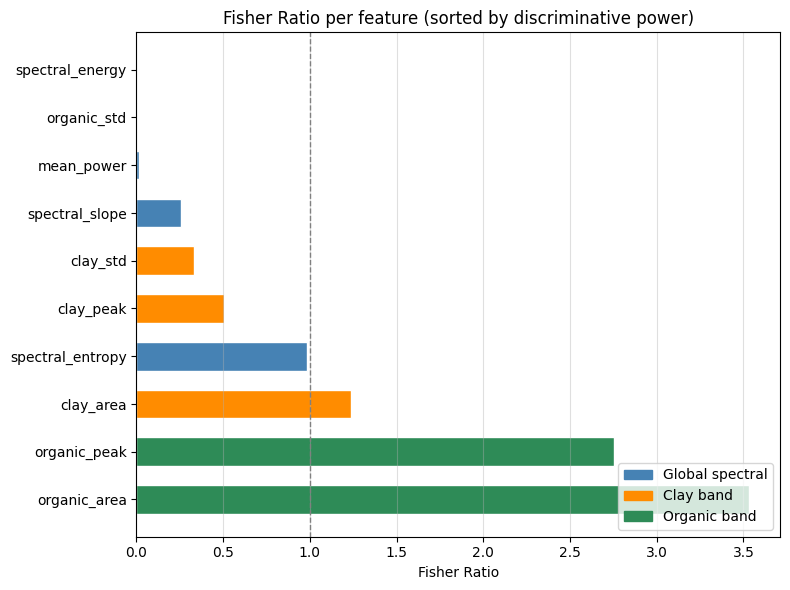

In [60]:
fisher_plot = fisher_results.copy()
fisher_plot['domain'] = fisher_plot['feature'].map(domain_labels)

bar_colors = fisher_plot['domain'].map(domain_palette).tolist()

plt.figure(figsize=(8, 6))
plt.barh(fisher_plot['feature'], fisher_plot['FisherRatio'],
         color=bar_colors, edgecolor='white', height=0.6)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1, label='Fisher Ratio = 1')
plt.xlabel('Fisher Ratio')
plt.title('Fisher Ratio per feature (sorted by discriminative power)')
plt.grid(axis='x', alpha=0.4)

from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in domain_palette.items()]
plt.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

<p align="justify">
The bar chart immediately identifies which features and domains have the greatest discriminative power. Features whose bars extend well beyond the reference threshold are the primary candidates for the classification models in the next section, while those close to or below the line add little additional information for separating the groups.
</p>

### Separability visualization

<p align="justify">
Finally, separability between groups is visualized by plotting the two features with the highest Fisher Ratio, obtained from the first two rows of <code>fisher_results</code> and stored in <code>top_two</code>. Each point represents a sample and the color indicates the group assigned by K-Means in <code>group_labels</code>. This type of plot allows visual evaluation of how well the groups are separated in the feature space without requiring a classification model.
</p>

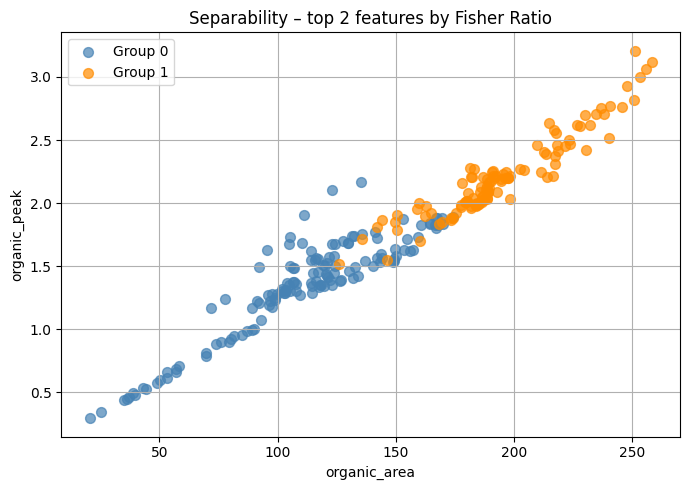

In [61]:
top_two = fisher_results['feature'].iloc[:2].tolist()

scatter_colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

plt.figure(figsize=(7, 5))
for g in np.unique(group_labels):
    sel = group_labels == g
    plt.scatter(X.loc[sel, top_two[0]], X.loc[sel, top_two[1]],
                label=f'Group {g}', alpha=0.7,
                color=scatter_colors[g], s=50)

plt.xlabel(top_two[0])
plt.ylabel(top_two[1])
plt.title("Separability – top 2 features by Fisher Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<p align="justify">
The scatter plot confirms the separability between the discovered groups. Well-defined groups appear as clearly separated point clouds, while overlapping groups indicate that the features in <code>top_two</code> are insufficient to distinguish them in two dimensions. This visualization complements the numerical results of <code>anova_results</code> and <code>fisher_results</code>, providing an intuitive interpretation of the feature space structure.
</p>

## 5. Data separability

<p align="justify">
This section evaluates how well the groups identified by K-Means can be separated using formal classification models. The goal is to determine whether the ten extracted features in <code>X</code> contain sufficient discriminative information to distinguish the groups reliably and reproducibly. Three models of increasing complexity are compared: a Baseline, a Logistic Regression, and a K-Nearest Neighbors classifier (kNN). All models are evaluated using 5-fold stratified cross-validation, ensuring each fold maintains the class proportions of the original dataset and that the evaluation does not depend on a single data split.
</p>

### Class labels

<p align="justify">
The K-Means class labels from <code>group_labels</code> are converted to a NumPy array <code>y</code> with <code>np.array()</code>. This format is required by Scikit-learn's evaluation functions. The class distribution is printed to verify balance between groups, since a marked imbalance can artificially inflate metrics such as accuracy.
</p>

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

y = np.array(group_labels)

print("Class distribution:")
for g in np.unique(y):
    print(f"  Group {g}: {(y == g).sum()} samples")

Class distribution:
  Group 0: 138 samples
  Group 1: 112 samples


<p align="justify">
Knowing the class distribution in <code>y</code> is fundamental for correctly interpreting classification metrics. For instance, if 80% of the samples belong to one group, a classifier that always predicts that group would achieve 80% accuracy without learning anything useful. This is why the Baseline is included as a minimum reference: any useful model must exceed it.
</p>

### Evaluation function

<p align="justify">
The function <code>run_evaluation()</code> centralizes the evaluation process for any classifier. It uses <code>StratifiedKFold</code> to split the data into <code>n_splits</code> balanced folds, and <code>cross_val_predict()</code> to obtain predictions <code>y_hat</code> for each sample when it was not used in training. Probabilities are stored in <code>proba</code> and the AUC in <code>auc_val</code>. The function returns a dictionary <code>metrics</code> with all metrics, along with <code>y_hat</code> and <code>proba</code>. This approach is more robust than a single train/test split because it averages performance across multiple folds, reducing the effect of randomness in data selection.
</p>

<p align="justify">
The computed metrics are: <strong>Accuracy</strong> (proportion of correct predictions), <strong>Precision</strong> (quality of positive predictions), <strong>Recall</strong> (ability to detect positives), <strong>F1-score</strong> (harmonic mean of Precision and Recall), and <strong>ROC-AUC</strong> (area under the ROC curve, where 0.5 is random and 1.0 is perfect separation).
</p>

In [63]:
def run_evaluation(clf, X, y, n_splits=5):
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_hat = cross_val_predict(clf, X, y, cv=skf)

    proba, auc_val = None, np.nan
    try:
        proba   = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]
        auc_val = roc_auc_score(y, proba)
    except Exception:
        pass

    metrics = {
        'accuracy':  accuracy_score(y, y_hat),
        'precision': precision_score(y, y_hat, pos_label=1, zero_division=0),
        'recall':    recall_score(y, y_hat,    pos_label=1, zero_division=0),
        'f1':        f1_score(y, y_hat,        pos_label=1, zero_division=0),
        'roc_auc':   auc_val
    }
    return metrics, y_hat, proba

### Model comparison

<p align="justify">
Three models are defined inside the dictionary <code>classifiers</code> to iterate over them in an organized manner. Each model is built as a <code>Pipeline</code> chaining <code>StandardScaler()</code>, which standardizes the features before training, necessary because kNN and Logistic Regression are sensitive to variable scale and the classifier itself. Using a Pipeline guarantees that standardization is learned only on the training data of each fold and applied correctly on the test data, preventing information leakage between folds. Results are accumulated in <code>summary_rows</code> and the best model by ROC-AUC is stored in <code>top_clf_name</code> and <code>top_proba</code>.
</p>

<p align="justify">
<strong>Baseline:</strong> always predicts the most frequent class without learning any pattern. Serves as the minimum reference threshold.
</p>

<p align="justify">
<strong>Logistic Regression:</strong> linear model that finds a hyperplane separating the classes in the feature space. Interpretable and efficient, but assumes linear separability.
</p>

<p align="justify">
<strong>kNN (k=5):</strong> classifies each sample based on the majority class of its 5 nearest neighbors in the feature space. Makes no assumptions about the decision boundary shape, so it can capture non-linear separation.
</p>

In [64]:
classifiers = {
    'Baseline':            make_pipeline(StandardScaler(), DummyClassifier(strategy='most_frequent')),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', random_state=42)),
    'kNN (k=5)':           make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
}

summary_rows = []
top_clf_name, top_auc, top_proba = None, -1, None

for clf_name, clf in classifiers.items():
    met, _, proba = run_evaluation(clf, X, y, n_splits=5)
    summary_rows.append({'Model': clf_name, **{k: round(v, 3) for k, v in met.items()}})
    if not np.isnan(met['roc_auc']) and met['roc_auc'] > top_auc:
        top_auc      = met['roc_auc']
        top_clf_name = clf_name
        top_proba    = proba

summary_df = pd.DataFrame(summary_rows)
print("Classification metrics:\n", summary_df)
print(f"\nBest model by ROC-AUC: {top_clf_name} ({top_auc:.3f})")

Classification metrics:
                  Model  accuracy  precision  recall     f1  roc_auc
0             Baseline     0.552      0.000   0.000  0.000    0.500
1  Logistic Regression     0.980      0.973   0.982  0.978    0.998
2            kNN (k=5)     0.968      0.981   0.946  0.964    0.990

Best model by ROC-AUC: Logistic Regression (0.998)


<p align="justify">
The table <code>summary_df</code> directly compares all three models from <code>classifiers</code>. The Baseline sets the minimum performance floor. If Logistic Regression and kNN significantly exceed the Baseline, it confirms that the extracted features contain real and discriminative information about the groups. If both models achieve similar F1 and ROC-AUC values, separability is robust regardless of classifier type.
</p>

### ROC curve of the best model

<p align="justify">
The ROC curve plots the true positive rate (sensitivity) on the Y axis against the false positive rate (1 − specificity) on the X axis, computed from <code>top_proba</code> and <code>y</code> at varying decision thresholds. A curve approaching the upper-left corner indicates a model with high sensitivity and low error rate. The dashed diagonal line represents random classification (ROC-AUC = 0.5) and serves as a visual reference. Only the model <code>top_clf_name</code>, which achieved the highest <code>top_auc</code>, is plotted.
</p>

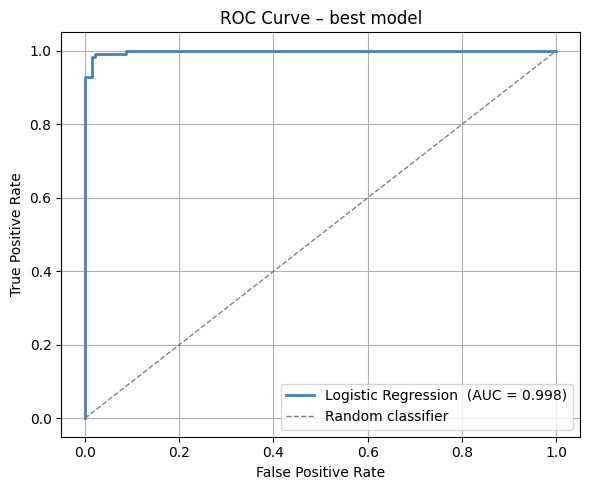

In [65]:
fpr, tpr, _ = roc_curve(y, top_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'{top_clf_name}  (AUC = {top_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
         label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – best model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<p align="justify">
The ROC curve of model <code>top_clf_name</code> allows visual evaluation of how well it separates the classes across different sensitivity levels. A <code>top_auc</code> close to 1.0 confirms that the extracted features, from both the global domain and the clay and organic matter bands, contain enough discriminative information to distinguish the K-Means groups with high reliability.
</p>

### Instrument separability analysis

<p align="justify">
Since the dataset contains samples measured with five different instruments, it is analyzed whether the features in <code>X</code> can also distinguish between instruments. This analysis is relevant because it confirms or refutes the transferability hypothesis: if the model correctly classifies the instrument from the normalized spectrum, it means SNV normalization did not fully remove instrumental differences and each device still leaves a characteristic spectral fingerprint.
</p>
<p align="justify">
<code>LabelEncoder()</code> stored in <code>label_enc</code> converts the instrument names to integer labels in <code>y_inst</code>. Cross-validation predictions are stored in <code>y_inst_pred</code>, the accuracy in <code>inst_accuracy</code>, the confusion matrix in <code>conf_mat</code>, and its visualization in <code>cm_disp</code>.
</p>

Accuracy classifying by instrument: 0.536


c:\Users\lufeh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\lufeh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\lufeh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is depr

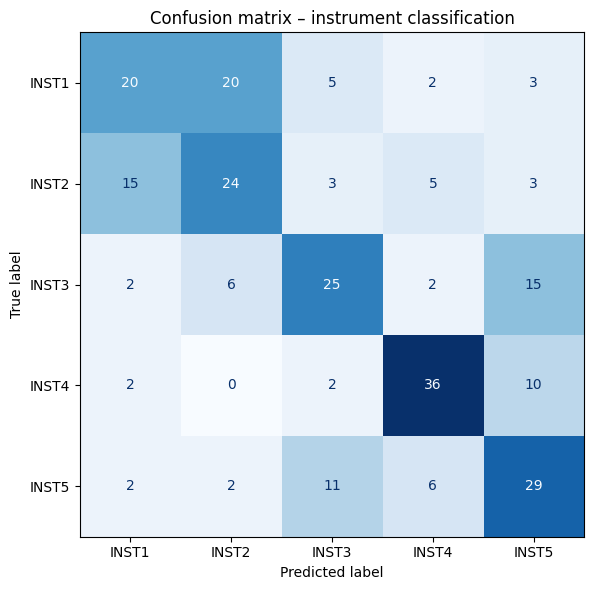

In [66]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

label_enc   = LabelEncoder()
y_inst      = label_enc.fit_transform(feature_table['instrument'])

skf_inst    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_inst_pred = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', random_state=42)),
    X, y_inst, cv=skf_inst
)

inst_accuracy = accuracy_score(y_inst, y_inst_pred)
print(f"Accuracy classifying by instrument: {inst_accuracy:.3f}")

conf_mat = confusion_matrix(y_inst, y_inst_pred)
cm_disp  = ConfusionMatrixDisplay(confusion_matrix=conf_mat,
                                   display_labels=label_enc.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
cm_disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion matrix – instrument classification")
plt.tight_layout()
plt.show()

<p align="justify">
The matrix <code>conf_mat</code> shows how many samples from each instrument were correctly classified (main diagonal) and how many were confused with another instrument (off-diagonal cells). The obtained result, <code>inst_accuracy = 0.536</code>, is clearly above the random baseline for five classes (0.20), indicating that the features retain a characteristic instrumental fingerprint even after SNV normalization. However, being far from 1.0, it also confirms that SNV did partially reduce inter-instrument differences but did not remove them completely. This result is consistent with the instrument transferability challenge reported by Safanelli et al. (2025) and supports the need for calibration transfer techniques when applying predictive models across different FTIR devices.
</p>